# Experimentations Notebook

This notebook is intended to run inside the `jani_in_python` container with the project mounted at `/jani_env`.

## Goal and Scope

This notebook runs an end-to-end DAgger repair pipeline and compares the three existing policy updaters:
- `SupervisedPolicyUpdater`
- `MILPPolicyUpdater`
- `SpecRepairPolicyUpdater`

- Use the same sampling/fault-detection loop for all methods
- Keep settings fair across updaters and seeds
- Collect complete logs and comparison-ready artifacts
- Report repair quality, safety, reward, and runtime

You can adjust benchmark file paths and experiment settings in the configuration cell below.

In [1]:
# Imports and notebook-wide setup
import json
import time
import random
from argparse import Namespace
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

from tensordict import TensorDict

from jani.env import JANIEnv
from pipeline import load_policy_checkpoint, save_policy_checkpoint, faults_to_tensordict, maybe_pick_init_state
from dagger.buffer import DAggerBuffer
from dagger.fault_collector import OracleFaultCollector
from dagger.policy_wrapper import NNPolicyWrapper
from dagger.sampler import StandardTraceSampler
from dagger.updater import SupervisedPolicyUpdater, MILPPolicyUpdater, SpecRepairPolicyUpdater

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

print('Torch:', torch.__version__)
print('Notebook ready.')

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-28 17:33:51,078	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Torch: 2.10.0+cu126
Notebook ready.


In [17]:
!python -m mask_ppo.train \
  --jani_model benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/model.jani \
  --jani_property benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/model.jani \
  --start_states benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/pa_model_random_starts_20000.jani \
  --eval_start_states benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/pa_model_random_starts_20000.jani \
  --goal_reward 1.0 --failure_reward -1.0 --unsafe_reward -0.01 \
  --max_steps 256 --total_timesteps 1000 --n_envs 1 --n_steps 256 \
  --n_eval_episodes 100 --experiment_name two_way_line_det \
  --log_dir /jani_env/logs/ppo/two_way_line_det \
  --model_save_dir /jani_env/artifacts/pipeline/checkpoints \
  --disable_eval --enumate_all_init_states --log_reward \
  --eval_freq 1025 --eval_safety --disable_wandb --verbose 1 --device cpu --seed 50

Creating training environment...
🤖 Oracle enabled: False
DEBUG: Setting up oracle with disable_cache=False, reduced_memory_mode=True
Reduced memory mode is enabled: the oracle cache will be cleared after each query.
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Training with hyperparameters: {'learning_rate': 0.0003, 'n_steps': 256, 'batch_size': 64, 'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95, 'clip_range': 0.2, 'ent_coef': 0.0, 'vf_coef': 0.5, 'max_grad_norm': 0.5}
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DEBUG: Setting up oracle with disable_cache=False, reduced_memory_mode=True
Reduced memory mode is enabl

In [3]:
!ls -lh benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40

total 153M
-rw-r--r-- 1 root root 852K Mar 27 21:42 model.jani
-rw-r--r-- 1 root root 153M Mar 27 21:42 pa_model_random_starts_20000.jani


In [2]:
# Experiment configuration
PROJECT_ROOT = Path('/jani_env') if Path('/jani_env').exists() else Path.cwd()
OUTPUT_ROOT = PROJECT_ROOT / 'artifacts' / 'pipeline_compare'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Pick one generated benchmark instance under benchmarks/two_way_line_det/
BENCHMARK_CASE = 'two_way_line_80_40'
BENCHMARK_DIR = PROJECT_ROOT / 'benchmarks_generator' / 'benchmarks' / 'two_way_line_det' / BENCHMARK_CASE

EXPERIMENT_CONFIG = {
    # Fill these benchmark paths according to your docker-generated data
    'jani_model': str(BENCHMARK_DIR / 'model.jani'),
    'jani_property': str(BENCHMARK_DIR / 'model.jani'),
    'start_states': str(BENCHMARK_DIR / 'pa_model_random_starts_20000.jani'),
    'objective': '',
    'failure_property': '',

    # Use a fixed initial policy to ensure fair comparison
    'initial_policy': str(PROJECT_ROOT / 'artifacts' / 'pipeline' / 'checkpoints' / 'final_actor.pth'),

    # Environment/reward setup
    'goal_reward': 1.0,
    'failure_reward': -1.0,
    'unsafe_reward': -0.01,
    'max_steps': 100,
    'disable_oracle_cache': False,
    'reduced_memory_mode': False,
    'sample_from_init_pool': True,

    # DAgger loop settings
    'max_iterations': 20,
    'traces_per_iteration': 100,
    'buffer_size': 50000,
    'accumulate_faults': True,

    # Updater hyperparameters
    'learning_rate': 1e-3,
    'updater_batch_size': 256,
    'updater_steps': 10,
    'spec_margin': 0.0,
    'spec_initial_penalty_weight': 1.0,
    'spec_max_penalty_weight': 1024.0,

    # Evaluation settings
    'eval_traces_per_iteration': 50,

    # Runtime
    'device': 'cpu'
}

# UPDATERS_TO_COMPARE = ['supervised', 'milp', 'specrepair']
UPDATERS_TO_COMPARE = ['supervised','milp']  # For quick testing
# SEEDS = [42, 43, 44]
SEEDS = [42]

print('Project root:', PROJECT_ROOT)
print('Benchmark dir:', BENCHMARK_DIR)
print('Output root:', OUTPUT_ROOT)
print('Updaters:', UPDATERS_TO_COMPARE)
print('Seeds:', SEEDS)

Project root: /jani_env
Benchmark dir: /jani_env/benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40
Output root: /jani_env/artifacts/pipeline_compare
Updaters: ['supervised', 'milp']
Seeds: [42]


In [3]:
# Core helpers for reproducible, fair experiments
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def validate_paths(cfg: Dict[str, Any]) -> None:
    required = ['jani_model', 'start_states', 'initial_policy']
    for key in required:
        p = Path(cfg[key])
        if not p.exists():
            raise FileNotFoundError(f'Missing required path for {key}: {p}')
    optional = ['jani_property', 'objective', 'failure_property']
    for key in optional:
        if cfg.get(key, '') and (not Path(cfg[key]).exists()):
            raise FileNotFoundError(f'Provided path for {key} does not exist: {cfg[key]}')


def build_env_from_cfg(cfg: Dict[str, Any], seed: int, use_oracle: bool = True) -> JANIEnv:
    return JANIEnv(
        jani_model_path=cfg['jani_model'],
        jani_property_path=cfg.get('jani_property', ''),
        start_states_path=cfg['start_states'],
        objective_path=cfg.get('objective', ''),
        failure_property_path=cfg.get('failure_property', ''),
        seed=seed,
        goal_reward=cfg['goal_reward'],
        failure_reward=cfg['failure_reward'],
        unsafe_reward=cfg['unsafe_reward'],
        use_oracle=use_oracle,
        disable_oracle_cache=cfg.get('disable_oracle_cache', False),
        reduced_memory_mode=cfg.get('reduced_memory_mode', False),
    )


def evaluate_policy_with_sampler(
    env: JANIEnv,
    policy_wrapper: NNPolicyWrapper,
    sampler: StandardTraceSampler,
    num_traces: int,
    max_steps: int,
    sample_from_pool: bool,
    rng: np.random.Generator,
    collector: OracleFaultCollector,
    collect_faults: bool = False,
) -> Dict[str, Any]:
    safe_count = 0
    total_steps = 0
    final_rewards = []
    total_faults = 0

    for _ in range(num_traces):
        init_state_idx = maybe_pick_init_state(env, rng, sample_from_pool)
        trace = sampler.sample_trace(
            env=env,
            policy=policy_wrapper,
            init_state_idx=init_state_idx,
            max_steps=max_steps,
        )
        total_steps += len(trace['observations'])
        final_rewards.append(float(trace.get('final_reward', 0.0)))
        if trace.get('is_safe_trajectory', False):
            safe_count += 1
        if collect_faults:
            total_faults += len(collector.collect_faults(trace))

    safety_rate = safe_count / max(num_traces, 1)
    avg_final_reward = float(np.mean(final_rewards)) if final_rewards else 0.0
    fault_rate = total_faults / max(total_steps, 1) if collect_faults else np.nan

    return {
        'safety_rate': safety_rate,
        'avg_final_reward': avg_final_reward,
        'eval_steps': total_steps,
        'eval_faults': total_faults,
        'eval_fault_rate': fault_rate,
    }


def prepare_faults_for_milp(faults: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    dataset = []
    for f in faults:
        mask = np.asarray(f['action_mask'], dtype=bool)
        applicable_actions = np.flatnonzero(mask).astype(int).tolist()
        dataset.append({
            'observation': np.asarray(f['observation'], dtype=np.float32),
            'action_mask': applicable_actions,
            'faulty_action': int(f['faulty_action']),
            'action': int(f['action']),
        })
    return dataset


def prepare_faults_for_spec_repair(faults: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    dataset = []
    for f in faults:
        dataset.append({
            'observation': np.asarray(f['observation'], dtype=np.float32),
            'action_mask': np.asarray(f['action_mask'], dtype=bool),
            'faulty_action': int(f['faulty_action']),
            'action': int(f['action']),
        })
    return dataset


def make_updater(
    updater_name: str,
    policy_model: torch.nn.Module,
    cfg: Dict[str, Any],
    device: torch.device,
) -> Any:
    if updater_name == 'supervised':
        optimizer = torch.optim.Adam(policy_model.parameters(), lr=cfg['learning_rate'])
        return SupervisedPolicyUpdater(
            optimizer=optimizer,
            batch_size=cfg['updater_batch_size'],
            steps_per_iteration=cfg['updater_steps'],
            device=device,
        )

    if updater_name == 'milp':
        return MILPPolicyUpdater()

    if updater_name == 'specrepair':
        optimizer = torch.optim.Adam(policy_model.parameters(), lr=cfg['learning_rate'])
        return SpecRepairPolicyUpdater(
            optimizer=optimizer,
            batch_size=cfg['updater_batch_size'],
            initial_penalty_weight=cfg['spec_initial_penalty_weight'],
            max_penalty_weight=cfg['spec_max_penalty_weight'],
            margin=cfg['spec_margin'],
            device=device,
        )

    raise ValueError(f'Unknown updater: {updater_name}')


print('Helper functions defined.')

Helper functions defined.


In [4]:
# End-to-end run function for one updater/seed pair
def run_single_experiment(
    updater_name: str,
    seed: int,
    cfg: Dict[str, Any],
    output_root: Path,
    verbose: bool = True,
) -> pd.DataFrame:
    set_all_seeds(seed)
    validate_paths(cfg)

    run_tag = f'{updater_name}_seed{seed}'
    run_dir = output_root / run_tag
    logs_dir = run_dir / 'logs'
    checkpoints_dir = run_dir / 'checkpoints'
    logs_dir.mkdir(parents=True, exist_ok=True)
    checkpoints_dir.mkdir(parents=True, exist_ok=True)

    device = torch.device(cfg.get('device', 'cpu'))
    policy_model = load_policy_checkpoint(Path(cfg['initial_policy']), device=device)
    policy_model.to(device)
    policy_wrapper = NNPolicyWrapper(policy_model, device=device)

    train_env = build_env_from_cfg(cfg, seed=seed, use_oracle=True)
    eval_env = build_env_from_cfg(cfg, seed=seed + 1000, use_oracle=True)
    obs_dim = int(train_env.observation_space.shape[0])
    n_actions = int(train_env.action_space.n)

    sampler = StandardTraceSampler()
    collector = OracleFaultCollector()
    updater = make_updater(updater_name, policy_model, cfg, device)
    replay_buffer = DAggerBuffer(buffer_size=cfg['buffer_size'])
    rng = np.random.default_rng(seed)

    all_faults_memory: List[Dict[str, Any]] = []
    rows: List[Dict[str, Any]] = []
    jsonl_path = logs_dir / 'iterations.jsonl'

    if verbose:
        print(f'[{run_tag}] Start run')
        print(f'[{run_tag}] Policy: {cfg["initial_policy"]}')

    run_t0 = time.time()
    for iteration in range(1, cfg['max_iterations'] + 1):
        iter_t0 = time.time()
        traces = []
        faults_iteration: List[Dict[str, Any]] = []
        total_steps = 0

        for _ in range(cfg['traces_per_iteration']):
            init_state_idx = maybe_pick_init_state(train_env, rng, cfg.get('sample_from_init_pool', False))
            trace = sampler.sample_trace(
                env=train_env,
                policy=policy_wrapper,
                init_state_idx=init_state_idx,
                max_steps=cfg['max_steps'],
            )
            traces.append(trace)
            total_steps += len(trace['observations'])
            faults_iteration.extend(collector.collect_faults(trace))

        num_faults = len(faults_iteration)
        fault_density = num_faults / max(total_steps, 1)

        if cfg.get('accumulate_faults', True):
            all_faults_memory.extend(faults_iteration)
        else:
            all_faults_memory = faults_iteration.copy()

        update_info: Dict[str, Any] = {}
        if num_faults > 0:
            if updater_name == 'supervised':
                if not cfg.get('accumulate_faults', True):
                    replay_buffer.empty()
                pos_td, neg_td = faults_to_tensordict(all_faults_memory, obs_dim=obs_dim, n_actions=n_actions)
                replay_buffer.add_samples(pos_td, neg_td)
                update_info = updater.update_policy(policy_model, replay_buffer)
            elif updater_name == 'milp':
                milp_dataset = prepare_faults_for_milp(all_faults_memory)
                update_info = updater.update_policy(policy_model, milp_dataset) or {}
            elif updater_name == 'specrepair':
                spec_dataset = prepare_faults_for_spec_repair(all_faults_memory)
                update_info = updater.update_policy(policy_model, spec_dataset) or {}

        eval_metrics = evaluate_policy_with_sampler(
            env=eval_env,
            policy_wrapper=policy_wrapper,
            sampler=sampler,
            num_traces=cfg['eval_traces_per_iteration'],
            max_steps=cfg['max_steps'],
            sample_from_pool=cfg.get('sample_from_init_pool', False),
            rng=rng,
            collector=collector,
            collect_faults=True,
        )

        iter_seconds = time.time() - iter_t0
        row = {
            'updater': updater_name,
            'seed': seed,
            'iteration': iteration,
            'num_traces': cfg['traces_per_iteration'],
            'total_steps': total_steps,
            'num_faults': num_faults,
            'fault_density': fault_density,
            'faults_memory_size': len(all_faults_memory),
            'iteration_seconds': iter_seconds,
            **eval_metrics,
        }
        row.update({f'update_{k}': v for k, v in update_info.items()})

        rows.append(row)
        with jsonl_path.open('a', encoding='utf-8') as f:
            f.write(json.dumps(row) + '\n')

        ckpt_path = checkpoints_dir / f'policy_iter_{iteration:03d}.pth'
        save_policy_checkpoint(policy_model, ckpt_path, input_dim=obs_dim, output_dim=n_actions)

        if verbose:
            print(
                f'[{run_tag}] iter={iteration:03d} faults={num_faults:4d} '
                f'safety={eval_metrics["safety_rate"]:.3f} reward={eval_metrics["avg_final_reward"]:.3f} '
                f't={iter_seconds:.1f}s'
            )

        if num_faults == 0:
            if verbose:
                print(f'[{run_tag}] Converged at iteration {iteration}.')
            break

    total_seconds = time.time() - run_t0
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df['run_total_seconds'] = total_seconds
        df.to_csv(logs_dir / 'iterations.csv', index=False)
        summary = {
            'updater': updater_name,
            'seed': seed,
            'iterations_ran': int(df['iteration'].max()),
            'final_faults': int(df['num_faults'].iloc[-1]),
            'final_safety_rate': float(df['safety_rate'].iloc[-1]),
            'final_avg_final_reward': float(df['avg_final_reward'].iloc[-1]),
            'best_safety_rate': float(df['safety_rate'].max()),
            'best_avg_final_reward': float(df['avg_final_reward'].max()),
            'total_seconds': float(total_seconds),
            'converged': bool(df['num_faults'].iloc[-1] == 0),
            'log_csv': str(logs_dir / 'iterations.csv'),
            'log_jsonl': str(jsonl_path),
        }
        with (logs_dir / 'summary.json').open('w', encoding='utf-8') as f:
            json.dump(summary, f, indent=2)

    final_path = checkpoints_dir / 'final_policy.pth'
    save_policy_checkpoint(policy_model, final_path, input_dim=obs_dim, output_dim=n_actions)

    if verbose:
        print(f'[{run_tag}] Finished. Total time: {total_seconds:.1f}s')
        print(f'[{run_tag}] Logs: {logs_dir}')

    return df

print('Run function ready.')

Run function ready.


In [5]:
# Quick config sanity check before launching long experiments
validate_paths(EXPERIMENT_CONFIG)
print('All required paths are valid.')

print('\nUsing benchmark files:')
for k in ['jani_model', 'jani_property', 'start_states', 'objective', 'failure_property']:
    print(f'- {k}: {EXPERIMENT_CONFIG.get(k, '')}')

print('\nInitial policy:', EXPERIMENT_CONFIG['initial_policy'])
print('Output directory:', OUTPUT_ROOT)

All required paths are valid.

Using benchmark files:
- jani_model: /jani_env/benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/model.jani
- jani_property: /jani_env/benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/model.jani
- start_states: /jani_env/benchmarks_generator/benchmarks/two_way_line_det/two_way_line_80_40/pa_model_random_starts_20000.jani
- objective: 
- failure_property: 

Initial policy: /jani_env/artifacts/pipeline/checkpoints/final_actor.pth
Output directory: /jani_env/artifacts/pipeline_compare


In [6]:
# Run all updater x seed experiments (this may take a while)
all_runs = []

for updater_name in UPDATERS_TO_COMPARE:
    for seed in SEEDS:
        print('\n' + '=' * 90)
        print(f'Running updater={updater_name}, seed={seed}')
        print('=' * 90)
        df_run = run_single_experiment(
            updater_name=updater_name,
            seed=seed,
            cfg=EXPERIMENT_CONFIG,
            output_root=OUTPUT_ROOT,
            verbose=True,
        )
        if len(df_run) > 0:
            all_runs.append(df_run)

if not all_runs:
    raise RuntimeError('No experiment results were produced. Check paths and config.')

results_df = pd.concat(all_runs, ignore_index=True)
results_csv = OUTPUT_ROOT / 'all_results.csv'
results_df.to_csv(results_csv, index=False)

print('\nAll experiments completed.')
print('Combined results:', results_csv)
print('Total rows:', len(results_df))
display(results_df.head())



Running updater=supervised, seed=42
DEBUG: Setting up oracle with disable_cache=False, reduced_memory_mode=False


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


DEBUG: Setting up oracle with disable_cache=False, reduced_memory_mode=False
[supervised_seed42] Start run
[supervised_seed42] Policy: /jani_env/artifacts/pipeline/checkpoints/final_actor.pth
2026-03-28 17:35:03,416 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([50000]) shape [END]
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
Positive buffer is empty, sampling only from negative buffer.
[supervised_seed42] iter=001 faults= 100 safety=0.000 reward=-1.000 t=9.9s
Pos

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/jani_env/dagger/updater.py:149: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor([f["observation"] for f in dataset], dtype=torch.float32)


Num output is: 5
Num hidden is 64
		- optimization begins
		- optimization done --> obj. value: 0.006, time: 0.161 s
[milp_seed42] iter=001 faults= 100 safety=0.020 reward=-0.980 t=13.7s
Num output is: 5
Num hidden is 64
		- optimization begins
		- optimization done --> obj. value: 0.015, time: 0.765 s
[milp_seed42] iter=002 faults=  99 safety=0.420 reward=-0.580 t=10.2s
Num output is: 5
Num hidden is 64
		- optimization begins
		- optimization done --> obj. value: 0.006, time: 1.742 s
[milp_seed42] iter=003 faults=  46 safety=0.440 reward=-0.560 t=16.0s
Num output is: 5
Num hidden is 64
		- optimization begins
		- optimization done --> obj. value: 0.009, time: 6.232 s
[milp_seed42] iter=004 faults=  54 safety=0.400 reward=-0.600 t=20.5s
Num output is: 5
Num hidden is 64
		- optimization begins
		- optimization done --> obj. value: 0.003, time: 8.797 s
[milp_seed42] iter=005 faults=  56 safety=0.720 reward=-0.280 t=25.0s
Num output is: 5
Num hidden is 64
		- optimization begins
		- opt

,updater,seed,iteration,num_traces,total_steps,num_faults,fault_density,faults_memory_size,iteration_seconds,safety_rate,avg_final_reward,eval_steps,eval_faults,eval_fault_rate,update_loss,run_total_seconds
0,supervised,42,1,100,1538,100,0.065020,100,9.901655,0.00,-1.0000,146,50,0.342466,1.084369,412.756967
1,supervised,42,2,100,284,100,0.352113,200,4.926145,0.04,-0.9600,826,48,0.058111,1.474273,412.756967
2,supervised,42,3,100,2563,89,0.034725,289,10.722531,0.26,-0.7400,1954,37,0.018936,0.748194,412.756967
3,supervised,42,4,100,4106,72,0.017535,361,16.903834,0.36,-0.6202,2559,32,0.012505,0.487625,412.756967
4,supervised,42,5,100,4145,76,0.018335,437,16.373310,0.44,-0.5600,2895,28,0.009672,0.320232,412.756967


In [7]:
# Build comparison tables

if 'results_df' not in globals():
    results_df = pd.read_csv(OUTPUT_ROOT / 'all_results.csv')

results_df = results_df.sort_values(['updater', 'seed', 'iteration']).reset_index(drop=True)

final_by_run = (
    results_df
    .groupby(['updater', 'seed'], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

summary_table = (
    final_by_run
    .groupby('updater', as_index=False)
    .agg(
        seeds=('seed', 'count'),
        converged_runs=('num_faults', lambda x: int((x == 0).sum())),
        final_faults_mean=('num_faults', 'mean'),
        final_faults_std=('num_faults', 'std'),
        final_safety_mean=('safety_rate', 'mean'),
        final_safety_std=('safety_rate', 'std'),
        final_reward_mean=('avg_final_reward', 'mean'),
        final_reward_std=('avg_final_reward', 'std'),
        best_safety_mean=('safety_rate', 'max'),
        runtime_mean_s=('run_total_seconds', 'mean'),
    )
)

leaderboard = summary_table.sort_values(
    by=['final_safety_mean', 'final_reward_mean', 'final_faults_mean'],
    ascending=[False, False, True],
).reset_index(drop=True)

print('Final-by-run snapshot:')
display(final_by_run[['updater', 'seed', 'iteration', 'num_faults', 'safety_rate', 'avg_final_reward', 'run_total_seconds']])

print('\nUpdater summary (mean +/- std across seeds):')
display(summary_table)

print('\nLeaderboard (high safety/reward, low faults):')
display(leaderboard)

summary_table.to_csv(OUTPUT_ROOT / 'summary_table.csv', index=False)
leaderboard.to_csv(OUTPUT_ROOT / 'leaderboard.csv', index=False)

Final-by-run snapshot:


,updater,seed,iteration,num_faults,safety_rate,avg_final_reward,run_total_seconds
0,milp,42,20,48,0.46,-0.54,2262.006837
1,supervised,42,20,2,1.00,0.00,412.756967



Updater summary (mean +/- std across seeds):


,updater,seeds,converged_runs,final_faults_mean,final_faults_std,final_safety_mean,final_safety_std,final_reward_mean,final_reward_std,best_safety_mean,runtime_mean_s
0,milp,1,0,48.0,NaN,0.46,NaN,-0.54,NaN,0.46,2262.006837
1,supervised,1,0,2.0,NaN,1.00,NaN,0.00,NaN,1.00,412.756967



Leaderboard (high safety/reward, low faults):


,updater,seeds,converged_runs,final_faults_mean,final_faults_std,final_safety_mean,final_safety_std,final_reward_mean,final_reward_std,best_safety_mean,runtime_mean_s
0,supervised,1,0,2.0,NaN,1.00,NaN,0.00,NaN,1.00,412.756967
1,milp,1,0,48.0,NaN,0.46,NaN,-0.54,NaN,0.46,2262.006837


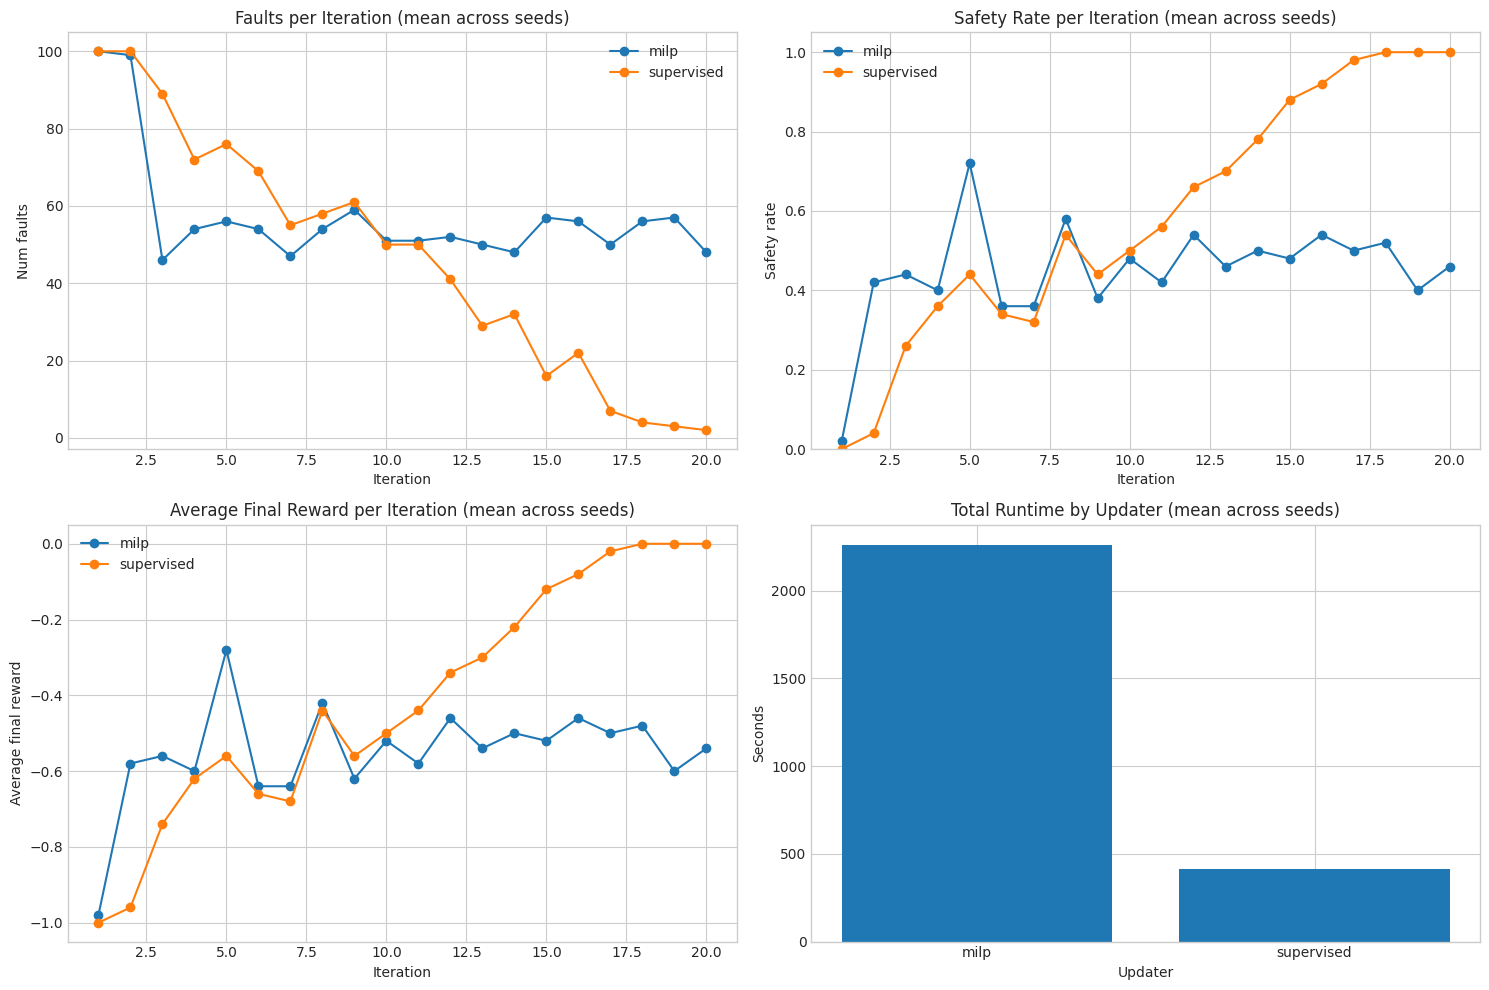

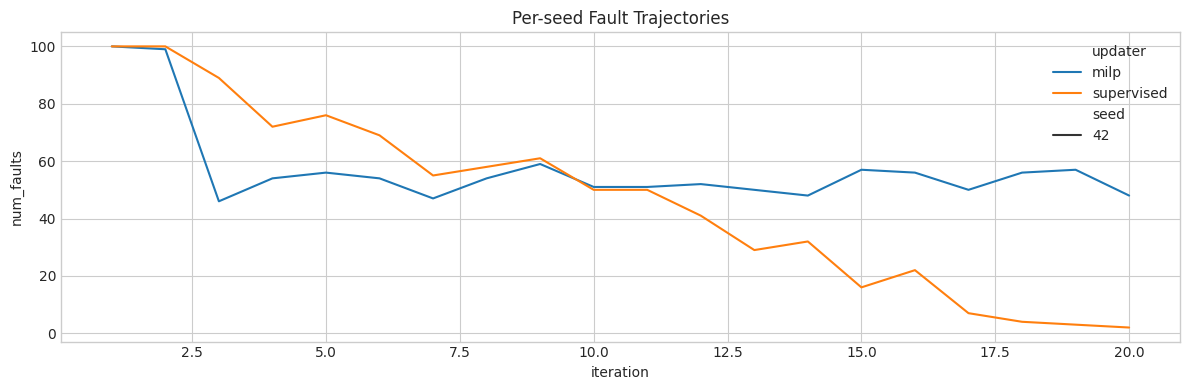

In [8]:
# Visual comparison: fault repair speed, safety trend, reward trend, runtime
if 'results_df' not in globals():
    results_df = pd.read_csv(OUTPUT_ROOT / 'all_results.csv')

plot_df = results_df.copy()
mean_curve = (
    plot_df
    .groupby(['updater', 'iteration'], as_index=False)
    .agg(
        num_faults_mean=('num_faults', 'mean'),
        safety_rate_mean=('safety_rate', 'mean'),
        reward_mean=('avg_final_reward', 'mean'),
        fault_density_mean=('fault_density', 'mean'),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for updater_name, g in mean_curve.groupby('updater'):
    axes[0, 0].plot(g['iteration'], g['num_faults_mean'], marker='o', label=updater_name)
axes[0, 0].set_title('Faults per Iteration (mean across seeds)')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Num faults')
axes[0, 0].legend()

for updater_name, g in mean_curve.groupby('updater'):
    axes[0, 1].plot(g['iteration'], g['safety_rate_mean'], marker='o', label=updater_name)
axes[0, 1].set_title('Safety Rate per Iteration (mean across seeds)')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Safety rate')
axes[0, 1].set_ylim(0.0, 1.05)
axes[0, 1].legend()

for updater_name, g in mean_curve.groupby('updater'):
    axes[1, 0].plot(g['iteration'], g['reward_mean'], marker='o', label=updater_name)
axes[1, 0].set_title('Average Final Reward per Iteration (mean across seeds)')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Average final reward')
axes[1, 0].legend()

final_by_run = plot_df.sort_values(['updater', 'seed', 'iteration']).groupby(['updater', 'seed'], as_index=False).tail(1)
runtime_by_updater = final_by_run.groupby('updater', as_index=False)['run_total_seconds'].mean()
axes[1, 1].bar(runtime_by_updater['updater'], runtime_by_updater['run_total_seconds'])
axes[1, 1].set_title('Total Runtime by Updater (mean across seeds)')
axes[1, 1].set_xlabel('Updater')
axes[1, 1].set_ylabel('Seconds')

plt.tight_layout()
plt.show()

# Optional detailed per-seed line plots with seaborn
if HAS_SEABORN:
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    sns.lineplot(data=plot_df, x='iteration', y='num_faults', hue='updater', style='seed', markers=False, dashes=True, ax=ax)
    ax.set_title('Per-seed Fault Trajectories')
    plt.tight_layout()
    plt.show()

In [9]:
# Auto-generate a concise experiment report
if 'results_df' not in globals():
    results_df = pd.read_csv(OUTPUT_ROOT / 'all_results.csv')

final_by_run = results_df.sort_values(['updater', 'seed', 'iteration']).groupby(['updater', 'seed'], as_index=False).tail(1)
summary_table = final_by_run.groupby('updater', as_index=False).agg(
    runs=('seed', 'count'),
    converged_runs=('num_faults', lambda x: int((x == 0).sum())),
    final_faults_mean=('num_faults', 'mean'),
    final_safety_mean=('safety_rate', 'mean'),
    final_reward_mean=('avg_final_reward', 'mean'),
    runtime_mean_s=('run_total_seconds', 'mean'),
)

ranked = summary_table.sort_values(
    by=['final_safety_mean', 'final_reward_mean', 'final_faults_mean'],
    ascending=[False, False, True],
).reset_index(drop=True)

lines = []
lines.append('# End-to-End DAgger Repair Comparison')
lines.append('')
lines.append('## Setup')
lines.append(f"- Updaters: {', '.join(sorted(results_df['updater'].unique().tolist()))}")
lines.append(f"- Seeds: {sorted(results_df['seed'].unique().tolist())}")
lines.append(f"- Max iterations: {int(results_df['iteration'].max())}")
lines.append(f"- Traces per iteration: {int(results_df['num_traces'].iloc[0])}")
lines.append('')
lines.append('## Results Summary')
for _, r in ranked.iterrows():
    lines.append(
        f"- {r['updater']}: converged {int(r['converged_runs'])}/{int(r['runs'])}, "
        f"final safety={r['final_safety_mean']:.3f}, final reward={r['final_reward_mean']:.3f}, "
        f"final faults={r['final_faults_mean']:.2f}, mean runtime={r['runtime_mean_s']:.1f}s"
    )
lines.append('')
lines.append('## Recommendation')
best = ranked.iloc[0]
lines.append(
    f"- Best overall under current settings: {best['updater']} "
    f"(highest safety/reward with low final faults)."
)
lines.append('- Validate this ranking on additional benchmark families before final conclusion.')

report_text = '\n'.join(lines)
report_path = OUTPUT_ROOT / 'report.md'
report_path.write_text(report_text, encoding='utf-8')

print(report_text)
print(f'\nSaved report to: {report_path}')

# End-to-End DAgger Repair Comparison

## Setup
- Updaters: milp, supervised
- Seeds: [42]
- Max iterations: 20
- Traces per iteration: 100

## Results Summary
- supervised: converged 0/1, final safety=1.000, final reward=0.000, final faults=2.00, mean runtime=412.8s
- milp: converged 0/1, final safety=0.460, final reward=-0.540, final faults=48.00, mean runtime=2262.0s

## Recommendation
- Best overall under current settings: supervised (highest safety/reward with low final faults).
- Validate this ranking on additional benchmark families before final conclusion.

Saved report to: /jani_env/artifacts/pipeline_compare/report.md
